# High Frequency Data and Limit Order Books

## Lab 4

AMRI Imad, CHIBA Nesrine, JAMAL Adonis

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from tqdm import tqdm

In [16]:
trades = np.array([[pd.read_csv(f"Data/stock{i}_day{j}_trades.csv.gz") for i in range(0, 3)] for j in range(0, 5)], dtype=object)
df_trades = pd.concat([df.assign(stock=i, day=j) for (j, i), df in np.ndenumerate(trades)], ignore_index=True)

1. **Brownian motions with Poisson sampling:** Take your results from Lab 2 Question 2 and add the Hayashi-Yoshida estimator to the plot. Comment.

We now implement the Hayashi-Yoshida estimator. Consiering two processes ($k=1,2$): $$dP_k (t) = \mu_k (t)dt + \sigma_k (t)dW_k (t)$$ with $(W_k(t))_t$ Brownian motions and $d\langle W_1, W_2 \rangle_t = \rho(t) dt$ for some deterministic functions $\rho, \sigma_1$ and $\sigma_2$.

The Hayashi-Yoshida covariance estimator is $$U_n = \sum_{i,j} \Delta P_1(I^i) \Delta P_2(J^j) \mathbf{1}_{\{I^i \cap J^j \neq \emptyset\}}$$

In [17]:
# Lab 2 Question 2
def simulate_poisson_sampled_bm(T, sigma1, sigma2, rho, mu1, mu2, n_paths=200, seed=0):
    rng    = np.random.default_rng(seed)
    paths  = []
    dt_fine = 1e-3         
    n_fine  = int(T / dt_fine)
    t_fine  = np.linspace(0, T, n_fine + 1)

    for _ in range(n_paths):
        # Correlated BM increments
        Z1 = rng.standard_normal(n_fine)
        Z2 = rho * Z1 + np.sqrt(1 - rho**2) * rng.standard_normal(n_fine)
        dW1 = sigma1 * np.sqrt(dt_fine) * Z1
        dW2 = sigma2 * np.sqrt(dt_fine) * Z2
        p1  = np.concatenate([[0], np.cumsum(dW1)])
        p2  = np.concatenate([[0], np.cumsum(dW2)])

        # Independent Poisson observation times
        obs1 = np.sort(rng.uniform(0, T, rng.poisson(mu1 * T)))
        obs2 = np.sort(rng.uniform(0, T, rng.poisson(mu2 * T)))

        # Interpolate BM at observation times
        p1_obs = np.interp(obs1, t_fine, p1)
        p2_obs = np.interp(obs2, t_fine, p2)
        paths.append((obs1, p1_obs, obs2, p2_obs))

    return paths


def realized_covariance(times1, prices1, times2, prices2, tau, T):
    """
    Previous-tick synchronization on a regular grid with spacing tau,
    then compute realized covariance.
    """
    grid = np.arange(0, T + tau, tau)
    # Previous-tick interpolation
    def prev_tick(obs_t, obs_p, grid):
        idx = np.searchsorted(obs_t, grid, side='right') - 1
        idx = np.clip(idx, 0, len(obs_p) - 1)
        return obs_p[idx]

    p1_g = prev_tick(times1, prices1, grid)
    p2_g = prev_tick(times2, prices2, grid)
    r1 = np.diff(p1_g)
    r2 = np.diff(p2_g)
    return np.sum(r1 * r2)


# Hayashi yoshida estimator
def hayashi_yoshida(times1, prices1, times2, prices2):
    dp1 = np.diff(prices1)
    dp2 = np.diff(prices2)
    n1, n2 = len(dp1), len(dp2)
    
    hy = 0.0
    j_start = 0
    for i in range(n1):
        a_i, b_i = times1[i], times1[i + 1]
        for j in range(j_start, n2):
            a_j, b_j = times2[j], times2[j + 1]
            if a_j >= b_i:
                break
            if b_j <= a_i:
                j_start = j + 1
                continue
            hy += dp1[i] * dp2[j]
    return hy


def hayashi_yoshida_correlation(times1, prices1, times2, prices2):
    hy_cov = hayashi_yoshida(times1, prices1, times2, prices2)
    rv1 = np.sum(np.diff(prices1) ** 2)
    rv2 = np.sum(np.diff(prices2) ** 2)
    return hy_cov / np.sqrt(rv1 * rv2)


In [18]:
# Parameters 
T_BM   = 3600.0 # 1 hour simulation
sigma1 = 0.01
sigma2 = 0.01
rho    = 0.7
mu1    = 1.0      
mu2    = 1.0
N_PATHS = 300
true_cov = rho * sigma1 * sigma2 * T_BM
print(f"True covariance [p1,p2]_T = rho*sigma1*sigma2*T = {true_cov:.4f}")

paths = simulate_poisson_sampled_bm(T_BM, sigma1, sigma2, rho, mu1, mu2, n_paths=N_PATHS, seed=42)

True covariance [p1,p2]_T = rho*sigma1*sigma2*T = 0.2520


In [20]:
tau_values = [10, 30, 60, 120, 300, 600]

rcov_means = []
rcov_stds  = []
for tau in tau_values:
    rcovs = [realized_covariance(*p, tau, T_BM) for p in paths]
    rcov_means.append(np.mean(rcovs))
    rcov_stds.append(np.std(rcovs))

In [19]:
hy_covs = [hayashi_yoshida(*p) for p in paths]
hy_mean = np.mean(hy_covs)
hy_std = np.std(hy_covs)

hy_corrs = [hayashi_yoshida_correlation(*p) for p in paths]
hy_corr_mean = np.mean(hy_corrs)
hy_corr_std = np.std(hy_corrs)

print(f"Hayashi-Yoshida covariance:  mean = {hy_mean:.6f},  std = {hy_std:.6f}")
print(f"True covariance:             {true_cov:.6f}")
print(f"Bias:                        {hy_mean - true_cov:.6f}")
print()
print(f"HY correlation estimator:    mean = {hy_corr_mean:.4f},  std = {hy_corr_std:.4f}")
print(f"True rho:                    {rho:.4f}")

Hayashi-Yoshida covariance:  mean = 0.250765,  std = 0.013673
True covariance:             0.252000
Bias:                        -0.001235

HY correlation estimator:    mean = 0.6980,  std = 0.0275
True rho:                    0.7000


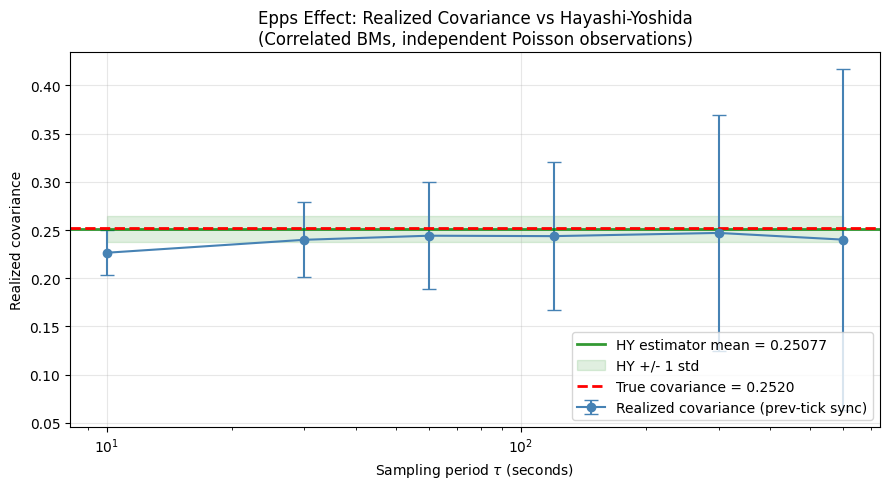


   tau (s) |      RC mean |     RC std |    RC bias
-------------------------------------------------------
        10 |      0.22646 |    0.02353 |   -0.02554
        30 |      0.23988 |    0.03880 |   -0.01212
        60 |      0.24413 |    0.05542 |   -0.00787
       120 |      0.24368 |    0.07643 |   -0.00832
       300 |      0.24701 |    0.12234 |   -0.00499
       600 |      0.24006 |    0.17688 |   -0.01194

        HY |      0.25077 |    0.01367 |   -0.00123


In [22]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.errorbar(tau_values, rcov_means, yerr=rcov_stds, fmt='o-',
            color='steelblue', capsize=5, label='Realized covariance (prev-tick sync)')

ax.axhline(hy_mean, color='green', linestyle='-', lw=2, alpha=0.8,
           label=f'HY estimator mean = {hy_mean:.5f}')
ax.fill_between(tau_values, hy_mean - hy_std, hy_mean + hy_std,
                color='green', alpha=0.12, label='HY +/- 1 std')

ax.axhline(true_cov, color='red', linestyle='--', lw=2,
           label=f'True covariance = {true_cov:.4f}')

ax.set_xscale('log')
ax.set_xlabel(r'Sampling period $\tau$ (seconds)')
ax.set_ylabel('Realized covariance')
ax.set_title('Epps Effect: Realized Covariance vs Hayashi-Yoshida\n'
             '(Correlated BMs, independent Poisson observations)')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n{'tau (s)':>10} | {'RC mean':>12} | {'RC std':>10} | {'RC bias':>10}")
print('-' * 55)
for tau, m, s in zip(tau_values, rcov_means, rcov_stds):
    print(f"{tau:>10} | {m:>12.5f} | {s:>10.5f} | {m - true_cov:>10.5f}")
print(f"\n{'HY':>10} | {hy_mean:>12.5f} | {hy_std:>10.5f} | {hy_mean - true_cov:>10.5f}")

We also show numerically that the estimator is consistent: $$ U_n \xrightarrow[n \xrightarrow{} +\infty]{\mathbb{P}} \int_0^T \sigma_1 (t) \sigma_2 (t) \rho (t) dt $$

Intensities:   0%|          | 0/3 [00:00<?, ?it/s]

Intensities: 100%|██████████| 3/3 [04:42<00:00, 94.23s/it] 


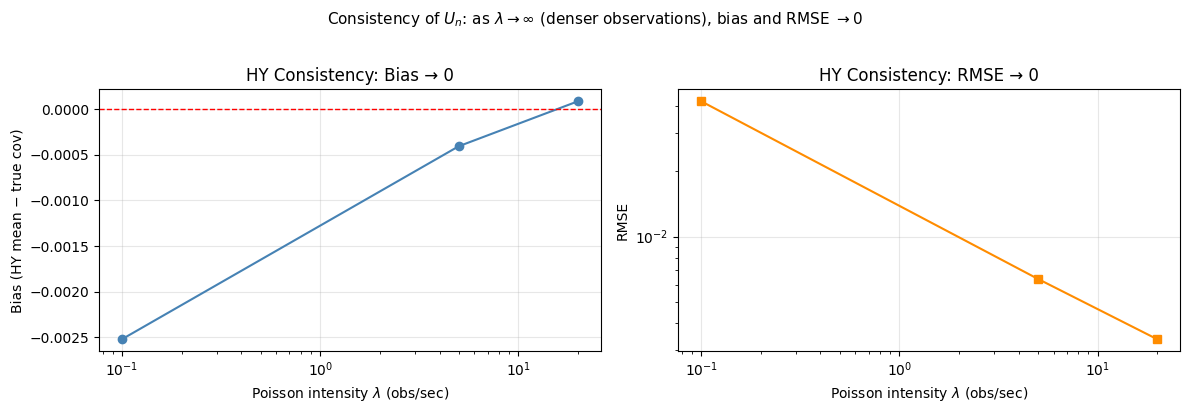

    lambda |         Bias |         RMSE
----------------------------------------
       0.1 |    -0.002522 |     0.041913
       5.0 |    -0.000405 |     0.006396
      20.0 |     0.000089 |     0.003377


In [ ]:
intensities = [0.1, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0]

n_mc = 300
rng_seed = 123

hy_bias = []
hy_rmse = []

for lam in tqdm(intensities, desc="Intensities"):
    sims = simulate_poisson_sampled_bm(T_BM, sigma1, sigma2, rho, lam, lam,
                                       n_paths=n_mc, seed=rng_seed)
    covs = np.array([hayashi_yoshida(*p) for p in sims])
    hy_bias.append(np.mean(covs) - true_cov)
    hy_rmse.append(np.sqrt(np.mean((covs - true_cov)**2)))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(intensities, hy_bias, 'o-', color='steelblue')
ax1.axhline(0, color='red', ls='--', lw=1)
ax1.set_xlabel(r'Poisson intensity $\lambda$ (obs/sec)')
ax1.set_ylabel('Bias (HY mean − true cov)')
ax1.set_title('HY Consistency: Bias → 0')
ax1.set_xscale('log')
ax1.grid(True, alpha=0.3)

ax2.plot(intensities, hy_rmse, 's-', color='darkorange')
ax2.set_xlabel(r'Poisson intensity $\lambda$ (obs/sec)')
ax2.set_ylabel('RMSE')
ax2.set_title('HY Consistency: RMSE → 0')
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.grid(True, alpha=0.3)

plt.suptitle(r'Consistency of $U_n$: as $\lambda \to \infty$ (denser observations), bias and RMSE $\to 0$',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

print(f"{'lambda':>10} | {'Bias':>12} | {'RMSE':>12}")
print('-' * 40)
for lam, b, r in zip(intensities, hy_bias, hy_rmse):
    print(f"{lam:>10.1f} | {b:>12.6f} | {r:>12.6f}")

We show numerically that the estimator is asymptatically gaussian.

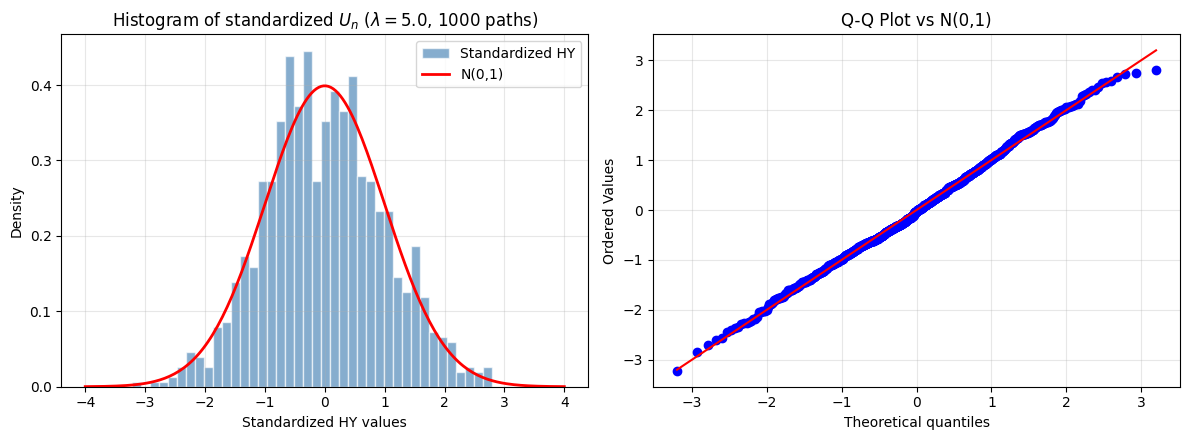

Shapiro-Wilk test:  statistic = 0.9976,  p-value = 0.1578
Jarque-Bera test:   statistic = 2.2763,  p-value = 0.3204

Skewness:  0.0942
Kurtosis:  -0.1384  (excess, should be ≈ 0 for Gaussian)

=> Both tests fail to reject normality at the 5% level: consistent with asymptotic Gaussianity.


In [26]:
lam_test = 5.0
n_mc_gauss = 1000
sims_gauss = simulate_poisson_sampled_bm(T_BM, sigma1, sigma2, rho,
                                         lam_test, lam_test,
                                         n_paths=n_mc_gauss, seed=456)
hy_vals = np.array([hayashi_yoshida(*p) for p in sims_gauss])

hy_centered = hy_vals - np.mean(hy_vals)
hy_standardized = hy_centered / np.std(hy_vals)

# tests
shapiro_stat, shapiro_p = stats.shapiro(hy_standardized)
jb_stat, jb_p = stats.jarque_bera(hy_standardized)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

ax1.hist(hy_standardized, bins=40, density=True, alpha=0.65, color='steelblue',
         edgecolor='white', label='Standardized HY')
x_grid = np.linspace(-4, 4, 200)
ax1.plot(x_grid, stats.norm.pdf(x_grid), 'r-', lw=2, label='N(0,1)')
ax1.set_xlabel('Standardized HY values')
ax1.set_ylabel('Density')
ax1.set_title(f'Histogram of standardized $U_n$ ($\\lambda={lam_test}$, {n_mc_gauss} paths)')
ax1.legend()
ax1.grid(True, alpha=0.3)

stats.probplot(hy_standardized, dist='norm', plot=ax2)
ax2.set_title('Q-Q Plot vs N(0,1)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Shapiro-Wilk test:  statistic = {shapiro_stat:.4f},  p-value = {shapiro_p:.4f}")
print(f"Jarque-Bera test:   statistic = {jb_stat:.4f},  p-value = {jb_p:.4f}")
print(f"\nSkewness:  {stats.skew(hy_standardized):.4f}")
print(f"Kurtosis:  {stats.kurtosis(hy_standardized):.4f}  (excess, should be ≈ 0 for Gaussian)")
if shapiro_p > 0.05 and jb_p > 0.05:
    print("\n=> Both tests fail to reject normality at the 5% level: consistent with asymptotic Gaussianity.")
else:
    print(f"\n=> Normality {'not rejected by Shapiro-Wilk' if shapiro_p > 0.05 else 'rejected by Shapiro-Wilk'} "
          f"and {'not rejected by Jarque-Bera' if jb_p > 0.05 else 'rejected by Jarque-Bera'} at 5%."
          f"\n   With finite samples, slight deviations are expected. The CLT is an *asymptotic* result.")

Finally we check the following property: In the case of constant $\rho$, $\sigma_1$ and $\sigma_2$, the correlation estimator is also consistent: $$ \frac{\sum_{i,j} \Delta P_1(I^i)\Delta P_2(J^j)\mathbf{1}_{I^i \cap J^j \neq \emptyset}}{\sqrt{\sum_i \Delta P_1(I^i)^2}\sqrt{\sum_j \Delta P_2(J^j)^2}} \to \rho \text{ in probability when } n \to +\infty. $$

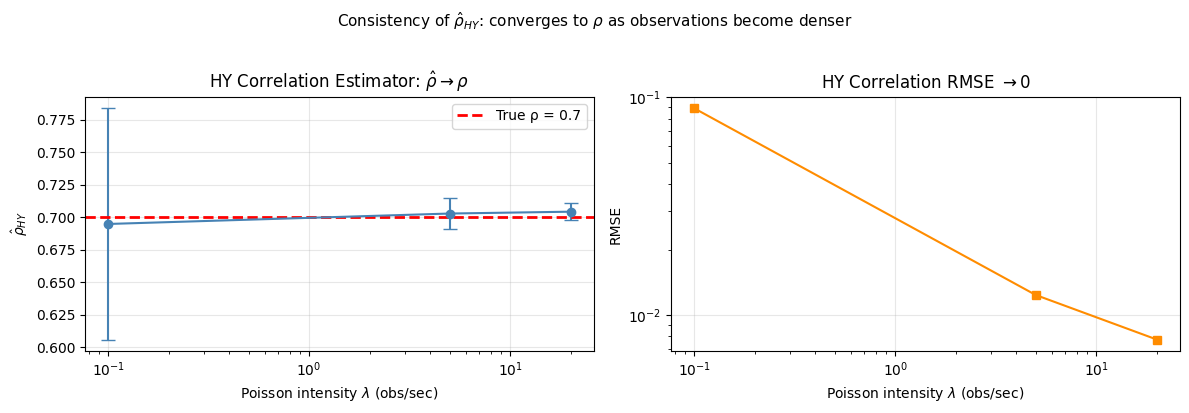

    lambda |  Mean rho_HY |        Std |       RMSE
--------------------------------------------------
       0.1 |       0.6948 |     0.0890 |     0.0891
       5.0 |       0.7028 |     0.0120 |     0.0124
      20.0 |       0.7043 |     0.0064 |     0.0077

True rho = 0.7


In [ ]:
intensities_corr = [0.1, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0]
n_mc_corr = 300

corr_means = []
corr_stds  = []
corr_rmse  = []

for lam in intensities_corr:
    sims = simulate_poisson_sampled_bm(T_BM, sigma1, sigma2, rho, lam, lam,
                                       n_paths=n_mc_corr, seed=789)
    corrs = np.array([hayashi_yoshida_correlation(*p) for p in sims])
    corr_means.append(np.mean(corrs))
    corr_stds.append(np.std(corrs))
    corr_rmse.append(np.sqrt(np.mean((corrs - rho)**2)))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.errorbar(intensities_corr, corr_means, yerr=corr_stds, fmt='o-',
             color='steelblue', capsize=5)
ax1.axhline(rho, color='red', ls='--', lw=2, label=f'True ρ = {rho}')
ax1.set_xlabel(r'Poisson intensity $\lambda$ (obs/sec)')
ax1.set_ylabel(r'$\hat{\rho}_{HY}$')
ax1.set_title(r'HY Correlation Estimator: $\hat{\rho} \to \rho$')
ax1.set_xscale('log')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(intensities_corr, corr_rmse, 's-', color='darkorange')
ax2.set_xlabel(r'Poisson intensity $\lambda$ (obs/sec)')
ax2.set_ylabel('RMSE')
ax2.set_title(r'HY Correlation RMSE $\to 0$')
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.grid(True, alpha=0.3)

plt.suptitle(r'Consistency of $\hat{\rho}_{HY}$: converges to $\rho$ as observations become denser',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

print(f"{'lambda':>10} | {'Mean rho_HY':>12} | {'Std':>10} | {'RMSE':>10}")
print('-' * 50)
for lam, m, s, r in zip(intensities_corr, corr_means, corr_stds, corr_rmse):
    print(f"{lam:>10.1f} | {m:>12.4f} | {s:>10.4f} | {r:>10.4f}")
print(f"\nTrue rho = {rho}")

### Comment on the results

The resulting plot clearly shows the advantage of the Hayashi-Yoshida estimator:

1. Epps effect in realized covariance

2. Unbiased HY estimator

3. Practical implication: In practice, the HY estimator is the preferred method for estimating covariance/correlation from asynchronously observed high-frequency data, as it avoids the artificial attenuation caused by the Epps effect while maintaining consistency and asymptotic normality.

2. **Signature plots and Epps effect:** On your dataset, estimate the integrated realized variances for each stock and the correlation between each pair of stocks using the standard estimators and the Hayashi-Yoshida estimators. Comment.

3. **Lead-lag estimation:** On your dataset, for each pair of stock, estimate the lead-lag
relationship using the Hayashi-Yoshida estimators. Comment.

4. **Hawkes process for trades:** Is a Hawkes process a good model for the time dynamics
of the trades in your dataset ? Explain your experiments in details and use statistical
arguments to support your answers.

5. **Hawkes fit on signature plots:** Fit the single stock Hawkes model of [1] on the
signature plot for each stock of your dataset. Comment.